# 📘 Taller Evaluativo (20%) - Análisis de Portafolio
### Curso: Ingeniería Financiera / Programación  
### Herramienta: Google Colab  
---
### 🎯 Objetivo
Este taller busca que comprendas qué es un análisis de portafolio, cómo se calculan y analizan sus métricas (rentabilidad, riesgo y correlación), y cómo se interpreta el resultado para tomar decisiones de inversión.

👉 **Importante:** No basta con ejecutar el código. Debes **completar los espacios en blanco**, responder las **preguntas de investigación** y redactar un **análisis final**.

## 1. Importación de librerías
Primero, importa las librerías necesarias para trabajar con datos financieros.

In [8]:
pip install yfinance

In [16]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


## 2. Descarga de datos
Usa `yfinance` para descargar los precios de **Google (GOOG)**, **Amazon (AMZN)** y **Microsoft (MSFT)** durante los últimos 3 años. Utiliza la columna `Adj Close`.

🔎 **Pregunta:** ¿Por qué es más adecuado usar `Adj Close` que `Close` para un análisis financiero?

R/: El valor Adj Close (cierre ajustado) refleja el precio real de la acción ajustado por dividendos, splits y otros eventos corporativos.
En cambio, Close solo muestra el precio de cierre del día sin ajustes.

Por eso, para análisis históricos y cálculos de rentabilidad es mejor usar Adj Close, porque representa de manera más precisa la evolución del valor real para un inversionista.

En pandas, un KeyError ocurre cuando intentas acceder a una columna que no existe en el DataFrame.
Pero el DataFrame que devuelve yf.download ya viene ajustado porque desde hace poco yfinance cambió su comportamiento:

Antes: devolvía "Open", "High", "Low", "Close", "Adj Close", "Volume".

Ahora: auto_adjust=True por defecto, entonces ya no incluye "Adj Close", solo entrega "Open", "High", "Low", "Close", "Volume", y ese "Close" ya es el ajustado.

Por eso "Adj Close" no existe → aparece el KeyError.

In [17]:
tickers = ['GOOG','AMZN','MSFT']
start = '2022-09-17'
end   = '2025-09-17'

# Forzar que devuelva la columna 'Adj Close'
datos = yf.download(tickers, start=start, end=end, auto_adjust=False)['Adj Close']
datos.head(5)

[*********************100%***********************]  3 of 3 completed


Ticker,AMZN,GOOG,MSFT
Date,,,
2022-09-19,124.660004,103.144150,238.584869
2022-09-20,122.190002,101.137886,236.565125
2022-09-21,118.540001,99.330261,233.150101
2022-09-22,117.309998,99.886452,235.130829
2022-09-23,113.779999,98.495972,232.145081


In [18]:
datos.tail(5) # Veo los últimos 5 datos

Ticker,AMZN,GOOG,MSFT
Date,,,
2025-09-10,230.330002,239.559998,500.369995
2025-09-11,229.949997,240.779999,501.010010
2025-09-12,228.149994,241.380005,509.899994
2025-09-15,231.429993,251.759995,515.359985
2025-09-16,234.050003,251.419998,509.040009


##3. Visualización de precios
Grafica en una misma figura la evolución de los precios de cierre ajustados de las tres acciones.

🔎 Pregunta: ¿Cuál de las tres acciones muestra mayor crecimiento en estos 3 años?

In [19]:
import matplotlib.pyplot as plt


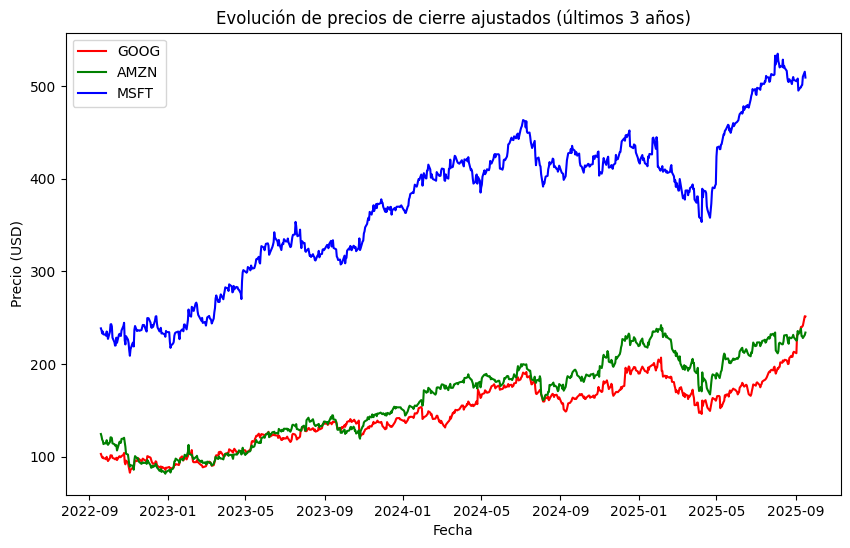

In [20]:
plt.figure(figsize=(10,6))

plt.plot(datos["GOOG"], label="GOOG", color="red")
plt.plot(datos["AMZN"], label="AMZN", color="green")
plt.plot(datos["MSFT"], label="MSFT", color="blue")

plt.title("Evolución de precios de cierre ajustados (últimos 3 años)")
plt.xlabel("Fecha")
plt.ylabel("Precio (USD)")
plt.legend()
plt.show()


#¿Cuál de las tres acciones muestra mayor crecimiento en estos 3 años?

In [21]:
# Precios iniciales y finales
precios_iniciales = datos.iloc[0]
precios_finales = datos.iloc[-1]

# Calcular diferencias
diferencias = precios_finales - precios_iniciales

# Mostrar resultados
print("📊 Comparación de precios en 3 años:\n")
for ticker in datos.columns:
    print(f"{ticker}:")
    print(f"   Precio inicial: {precios_iniciales[ticker]:.2f} USD")
    print(f"   Precio final:   {precios_finales[ticker]:.2f} USD")
    print(f"   Diferencia:     {diferencias[ticker]:.2f} USD\n")

# Identificar la acción con mayor crecimiento
ganador = diferencias.idxmax()
print(f"🏆 La acción con mayor crecimiento absoluto en precio es: {ganador}")


📊 Comparación de precios en 3 años:

AMZN:
   Precio inicial: 124.66 USD
   Precio final:   234.05 USD
   Diferencia:     109.39 USD

GOOG:
   Precio inicial: 103.14 USD
   Precio final:   251.42 USD
   Diferencia:     148.28 USD

MSFT:
   Precio inicial: 238.58 USD
   Precio final:   509.04 USD
   Diferencia:     270.46 USD

🏆 La acción con mayor crecimiento absoluto en precio es: MSFT


## 4. Rentabilidades
Calcula las rentabilidades logarítmicas diarias y grafícalas.

🔎 Pregunta: ¿Qué diferencias encuentras entre observar precios y observar rentabilidades?

#Formula

In [31]:
# Calcular rentabilidades logarítmicas diarias
rendimientos = np.log(datos / datos.shift(1))
rendimientos.head()


Ticker,AMZN,GOOG,MSFT
Date,,,
2022-09-19,NaN,NaN,NaN
2022-09-20,-0.020013,-0.019643,-0.008502
2022-09-21,-0.030327,-0.018035,-0.014541
2022-09-22,-0.010430,0.005584,0.008460
2022-09-23,-0.030553,-0.014018,-0.012780


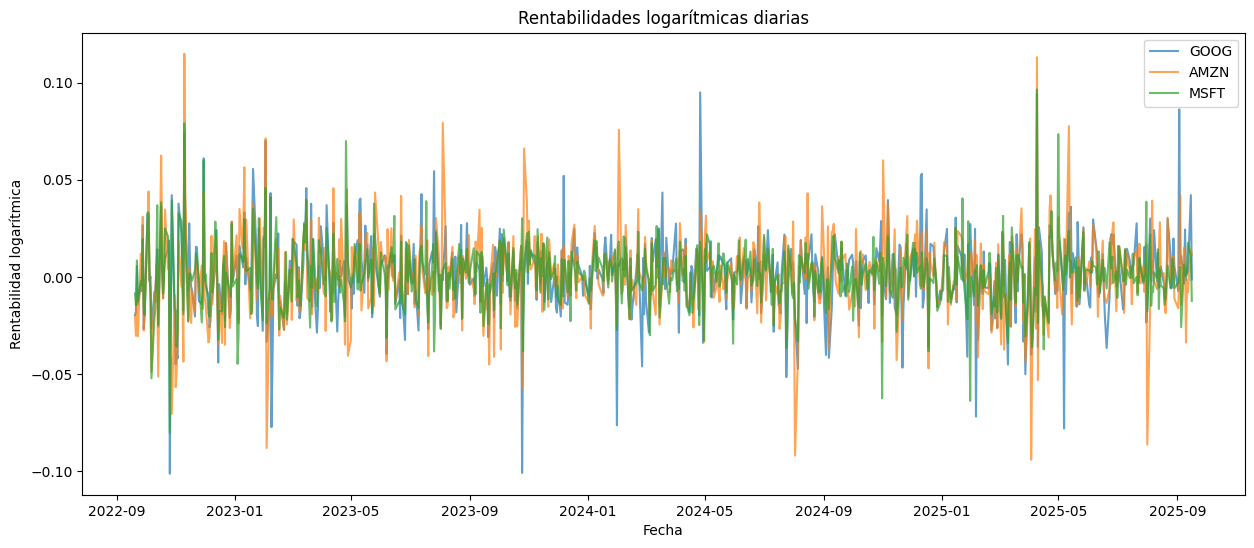

In [29]:
plt.figure(figsize=(15,6))
plt.plot(rendimientos["GOOG"], label="GOOG", alpha=0.7)
plt.plot(rendimientos["AMZN"], label="AMZN", alpha=0.7)
plt.plot(rendimientos["MSFT"], label="MSFT", alpha=0.7)

plt.title("Rentabilidades logarítmicas diarias")
plt.xlabel("Fecha")
plt.ylabel("Rentabilidad logarítmica")
plt.legend()
plt.show()
